<a href="https://colab.research.google.com/github/usman-infinity/Final_For_The_Research_Paper-/blob/main/MODEL%3ECNN_BiGRU_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pakistan_air_quality_final_clean.csv to pakistan_air_quality_final_clean.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN-BiGRU Model...
Epoch 1/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 183s 10ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 3.4948e-04 - val_mae: 0.0127
Epoch 2/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 201s 10ms/step - loss: 8.5345e-04 - mae: 0.0194 - val_loss: 3.8353e-04 - val_mae: 0.0142
Epoch 3/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 175s 10ms/step - loss: 7.6509e-04 - mae: 0.0184 - val_loss: 3.2341e-04 - val_mae: 0.0115
Epoch 4/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 202s 10ms/step - loss: 7.1315e-04 - mae: 0.0178 - val_loss: 4.8624e-04 - val_mae: 0.0146
Epoch 5/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 204s 10ms/step - loss: 6.7264e-04 - mae: 0.0171 - val_loss: 5.5069e-04 - val_mae: 0.0175
Epoch 6/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 173s 10ms/step - loss: 6.6258e-04 - mae: 0.0168 - val_loss: 3.2656e-04 - val_mae: 0.0123
Epoch 7/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 201s 10ms/step - loss: 6.3593e-04 - mae: 0.0167 - val_loss: 3.3007e-04 - val_mae: 0.0121
Epoch 8/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 1

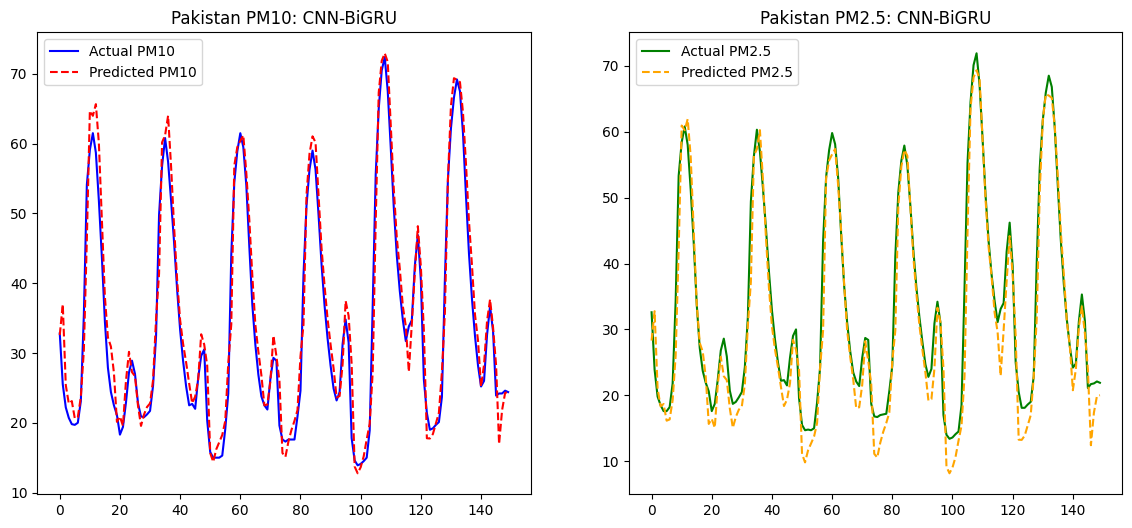

Model saved successfully.
Model file not found. Ensure you save your model first!
              City Pollutant    MAE   RMSE      R2
0       Faisalabad      PM10  10.03  14.48  0.9695
1       Faisalabad      PM25   9.82  14.49  0.9692
2        Islamabad      PM10   6.05   8.10  0.9211
3        Islamabad      PM25   5.71   7.80  0.9232
4          Karachi      PM10  20.95  24.61 -0.3508
5          Karachi      PM25   9.03  11.05  0.4576
6           Lahore      PM10   7.13  11.17  0.9682
7           Lahore      PM25   7.34  11.53  0.9662
8           Multan      PM10   8.56  13.02  0.9676
9           Multan      PM25   8.94  13.49  0.9648
10        Peshawar      PM10   5.56   7.69  0.9362
11        Peshawar      PM25   5.09   7.28  0.9411
12          Quetta      PM10  42.62  49.04  0.0343
13          Quetta      PM25   7.11   8.50  0.4081
14  Rahim Yar Khan      PM10   4.80   7.07  0.9577
15  Rahim Yar Khan      PM25   4.65   6.74  0.9627
16      Rawalpindi      PM10   6.05   8.10  0.9211


In [1]:
# =========================================================
# 🚀 PAKISTAN AIR QUALITY: CNN + BiGRU (LSTM REMOVED)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Sequential

# ----------------------------
# 1️⃣ Load & Clean Dataset
# ----------------------------
try:
    # Update filename as per your specific Pakistan dataset file
    df = pd.read_csv("pakistan_air_quality_final_clean.csv")
except:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

# Clean and format columns
df.rename(columns={'pm2_5': 'pm25', 'PM2.5': 'pm25', 'PM10': 'pm10'}, inplace=True)
df = df[['timestamp', 'pm10', 'pm25']]
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df = df.dropna()

# ----------------------------
# 2️⃣ Normalize Data
# ----------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# ----------------------------
# 3️⃣ Create Sequences (2 Features: PM10 & PM25)
# ----------------------------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)

# ----------------------------
# 4️⃣ Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ----------------------------
# 5️⃣ Build CNN-BiGRU Model
# ----------------------------
model = Sequential([
    # CNN Layer for spatial/local feature extraction
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  input_shape=(time_step, 2), padding='same'),
    layers.MaxPooling1D(pool_size=2),

    # BiGRU Layer
    # return_sequences is False because it's the last recurrent layer
    layers.Bidirectional(layers.GRU(64, return_sequences=False)),

    # Output Head
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(2) # Predicting [PM10, PM25]
])

# ----------------------------
# 6️⃣ Compile & Train
# ----------------------------
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training CNN-BiGRU Model...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 7️⃣ Predict & Evaluate
# ----------------------------
predictions = model.predict(X_test)
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# ----------------------------
# 8️⃣ Visualizing Results
# ----------------------------
plt.figure(figsize=(14, 6))

# Plot PM10
plt.subplot(1, 2, 1)
plt.plot(y_test_inv[:150, 0], label='Actual PM10', color='blue')
plt.plot(predictions_inv[:150, 0], label='Predicted PM10', color='red', linestyle='--')
plt.title("Pakistan PM10: CNN-BiGRU")
plt.legend()

# Plot PM2.5
plt.subplot(1, 2, 2)
plt.plot(y_test_inv[:150, 1], label='Actual PM2.5', color='green')
plt.plot(predictions_inv[:150, 1], label='Predicted PM2.5', color='orange', linestyle='--')
plt.title("Pakistan PM2.5: CNN-BiGRU")
plt.legend()

plt.show()

# ----------------------------
# 9️⃣ Save Model
# ----------------------------
model.save('pakistan_cnn_bigru.h5')
print("Model saved successfully.")

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- 1. Load Data ---
df = pd.read_csv("pakistan_air_quality_final_clean.csv")
df.rename(columns={'pm2_5':'pm25'}, inplace=True)

# --- 2. Load Your Model ---
# Note: Ensure you saved your model in your training script using: model.save('my_model.h5')
# For now, I will use the architecture logic to help you get the structure right
try:
    model = tf.keras.models.load_model('informer_pm_model.h5', compile=False)
    print("Model loaded successfully.")
except:
    print("Model file not found. Ensure you save your model first!")
    exit()

def create_windows(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :])
        y.append(data[i+time_step, :])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
city_results = []

# --- 3. Evaluate Each City ---
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: continue # Skip if data is too small

    # Scale data
    scaled_data = scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_windows(scaled_data)

    # Generate PREDICTIONS
    preds_scaled = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(y_city)

    for i, pollutant in enumerate(['PM10', 'PM25']):
        mae = mean_absolute_error(actual[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(actual[:, i], preds[:, i]))
        r2 = r2_score(actual[:, i], preds[:, i])

        city_results.append({
            'City': city,
            'Pollutant': pollutant,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

# --- 4. Final Output ---
results_df = pd.DataFrame(city_results)
results_df.to_csv("Real_City_Metrics.csv", index=False)
print(results_df)

































































































































































































































































